# Equilibrium diagnostics from monthly global-mean CAM/CLM files

This notebook reads the NetCDF files created by `concatenate_monthly_global_means.sh` and produces one figure per variable, saved under `equilibrium_figs/equilibrium_<CASENAME>/`.

Expected input files:

```text
equilibrium_output/equilibrium_<CASENAME>/cam_monthly_globalmean.nc
equilibrium_output/equilibrium_<CASENAME>/clm_monthly_globalmean.nc
```

Main diagnostics:

- CAM scalar variables: monthly time series, 3-year rolling mean, and derivative of the 3-year rolling mean.
- CAM gases: global-mean vertical profiles from the original gas variables, plus column-burden time series from precomputed `*_COLBURDEN` variables created by the preprocessing script.
- CLM variables: monthly time series at approximately 1 m depth for depth-resolved variables, 20-year rolling mean, and derivative of the 20-year rolling mean.

Important: this notebook no longer tries to compute CAM column burdens itself. The physically better calculation is done in the NCO preprocessing script before horizontal averaging.

In [16]:
# ============================================================
# User settings
# ============================================================

CASENAME = "NF2100ssp585norbc_tropstratchem_quick_spinup_lcc_f19_f19_20260428" #-just clm
#"NF2100ssp585norbc_tropstratchem_spinup_f19_f19-3" - just clm
#"NF2000norbc_tropstratchem_spinup_f19_f19" - clm and cam pre column burden

# If you run this notebook from the directory containing equilibrium_output/, keep BASE_DIR = "."
BASE_DIR = "."

# Rolling windows, in years
CAM_ROLLING_YEARS = 5
CLM_ROLLING_YEARS = 5

# Depth requested for CLM depth-resolved variables
TARGET_SOIL_DEPTH_M = 1.0

# Figure settings
FIG_DPI = 180
SHOW_FIGURES = True
SAVE_FIGURES = True


In [9]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib as mpl

warnings.filterwarnings("ignore", category=FutureWarning)

case_dir = Path(BASE_DIR) / "equilibrium_output" / f"equilibrium_{CASENAME}"
fig_dir = Path(BASE_DIR) / "equilibrium_figs" / f"equilibrium_{CASENAME}"
fig_dir.mkdir(parents=True, exist_ok=True)

CAM_FILE = case_dir / "cam_monthly_globalmean.nc"
CLM_FILE = case_dir / "clm_monthly_globalmean.nc"

# Optional fallbacks, useful if older files have different names
CAM_FALLBACKS = [case_dir / "cam_monthly.nc", case_dir / "cam_annual.nc"]
CLM_FALLBACKS = [case_dir / "clm_monthly.nc", case_dir / "clm_annual.nc"]

print(f"Case: {CASENAME}")
print(f"Input directory: {case_dir}")
print(f"Figure directory: {fig_dir}")


Case: NF2100ssp585norbc_tropstratchem_quick_spinup_lcc_f19_f19_20260428
Input directory: equilibrium_output/equilibrium_NF2100ssp585norbc_tropstratchem_quick_spinup_lcc_f19_f19_20260428
Figure directory: equilibrium_figs/equilibrium_NF2100ssp585norbc_tropstratchem_quick_spinup_lcc_f19_f19_20260428


In [10]:
CAM_TIME_SERIES_VARS = [
    "RESTOM",   # net radiative flux at TOA = FSNT - FLNT
    "TREFHT",   # 2 m air temperature
    "FSNT",     # net solar flux at TOA
    "FLNT",     # net longwave flux at TOA
    "TS",       # surface temperature
]

# Gas variables for global-mean vertical profiles.
# If the corresponding *_COLBURDEN variable exists, the notebook also plots the column burden.
CAM_GAS_VARS = [
    "SF6",
    "CFC115",
    "CFC114",
    "N2O",
    "CFC12",
    "CFC113",
    "CFC11",
    "HCFC142B",
    "HCFC22",
    "CH4",
    "HCFC141B",
    "OCS",
    "CH3CL",
    "CH3BR",
    "CH2BR2",
    "CHBR3",
    "CO2",      # profile only unless CO2_COLBURDEN was also produced
]

CLM_VARS = [
    "GPP",      # gross primary productivity
    "TOTVEGC",  # total vegetation carbon
    "TOTVEGN",  # total vegetation nitrogen
    "TWS",      # total water storage
    "H2OSOI",   # soil water
    "TSOI",     # soil temperature
]

CLM_DEPTH_VARS = ["TWS", "H2OSOI", "TSOI"]

## Helper functions

In [11]:
def existing_file(primary, fallbacks=None):
    """Return the first existing file among primary and fallbacks."""
    candidates = [Path(primary)] + [Path(f) for f in (fallbacks or [])]
    for f in candidates:
        if f.exists():
            return f
    raise FileNotFoundError("None of these files exist:\n" + "\n".join(str(f) for f in candidates))


def open_dataset_if_exists(primary, fallbacks=None):
    try:
        f = existing_file(primary, fallbacks)
    except FileNotFoundError as exc:
        print(exc)
        return None
    print(f"Opening: {f}")
    return xr.open_dataset(f, decode_times=True)


def time_as_years(time_coord):
    """Return decimal years suitable for plotting and derivatives.

    This avoids problems with cftime plotting on systems without nc-time-axis.
    """
    values = np.asarray(time_coord.values)
    if values.size == 0:
        return values.astype(float)

    first = values[0]

    # cftime-like objects
    if hasattr(first, "year") and hasattr(first, "month"):
        years = np.array([
            t.year + (getattr(t, "month", 1) - 0.5) / 12.0
            for t in values
        ], dtype=float)
        return years

    # numpy/pandas datetimes
    try:
        dt = pd.to_datetime(values)
        return dt.year.values + (dt.month.values - 0.5) / 12.0
    except Exception:
        pass

    # Numeric fallback: assume monthly samples starting at zero
    return np.arange(values.size, dtype=float) / 12.0


def infer_samples_per_year(years):
    years = np.asarray(years, dtype=float)
    if years.size < 3:
        return 12
    dt = np.nanmedian(np.diff(years))
    if not np.isfinite(dt) or dt <= 0:
        return 12
    return max(1, int(round(1.0 / dt)))


def get_units(da):
    return da.attrs.get("units", "")


def get_long_name(da, default=None):
    return da.attrs.get("long_name", da.attrs.get("standard_name", default or da.name))


def select_nearest_depth(da, target_depth_m=1.0):
    """Select the depth level nearest target_depth_m for CLM variables.

    Handles common CLM vertical dimensions/coordinates: levsoi, levgrnd, soil_depth,
    zsoi, depth. If no depth-like dimension is found, returns the input unchanged.
    """
    depth_names = ["levsoi", "levgrnd", "soil_depth", "zsoi", "depth"]

    for name in depth_names:
        if name in da.dims:
            coord = da.coords.get(name, None)
            if coord is None:
                idx = 0
                selected = da.isel({name: idx})
                selected.attrs.update(da.attrs)
                selected.attrs["selected_depth_note"] = f"No coordinate for {name}; selected index 0."
                return selected

            vals = np.asarray(coord.values, dtype=float)
            units = str(coord.attrs.get("units", "")).lower()
            vals_m = vals.copy()
            if units in ["cm", "centimeter", "centimeters"]:
                vals_m = vals / 100.0
            elif units in ["mm", "millimeter", "millimeters"]:
                vals_m = vals / 1000.0

            idx = int(np.nanargmin(np.abs(vals_m - target_depth_m)))
            selected = da.isel({name: idx})
            selected.attrs.update(da.attrs)
            selected.attrs["selected_depth_m"] = float(vals_m[idx])
            selected.attrs["selected_depth_dim"] = name
            return selected

    return da


def squeeze_to_1d_time_series(da):
    """Make a DataArray plottable as a 1-D time series.

    The NCO script should have removed lat/lon, but scalar variables can still carry
    singleton dimensions. Non-singleton non-time dimensions are averaged only as a
    last resort and a note is stored in attrs.
    """
    da = da.squeeze(drop=True)
    non_time_dims = [d for d in da.dims if d != "time"]
    if non_time_dims:
        da = da.mean(dim=non_time_dims, skipna=True)
        da.attrs["plot_note"] = f"Averaged remaining non-time dimensions: {non_time_dims}"
    return da


def rolling_mean_1d(y, window_samples):
    s = pd.Series(np.asarray(y, dtype=float))
    return s.rolling(window=window_samples, center=True, min_periods=max(2, window_samples // 2)).mean().to_numpy()


def derivative_per_year(years, y):
    years = np.asarray(years, dtype=float)
    y = np.asarray(y, dtype=float)
    ok = np.isfinite(years) & np.isfinite(y)
    out = np.full_like(y, np.nan, dtype=float)
    if ok.sum() < 3:
        return out
    out[ok] = np.gradient(y[ok], years[ok])
    return out


def save_or_show(fig, filename):
    if SAVE_FIGURES:
        fig.savefig(fig_dir / filename, dpi=FIG_DPI, bbox_inches="tight", transparent=False)
    if SHOW_FIGURES:
        plt.show()
    else:
        plt.close(fig)


def safe_filename(text):
    return "".join(c if c.isalnum() or c in ["_", "-", "."] else "_" for c in text)


## Load datasets

In [12]:
cam = open_dataset_if_exists(CAM_FILE, CAM_FALLBACKS)
clm = open_dataset_if_exists(CLM_FILE, CLM_FALLBACKS)

if cam is not None:
    print("\nCAM variables in file:")
    print(sorted(list(cam.data_vars)))

if clm is not None:
    print("\nCLM variables in file:")
    print(sorted(list(clm.data_vars)))

None of these files exist:
equilibrium_output/equilibrium_NF2100ssp585norbc_tropstratchem_quick_spinup_lcc_f19_f19_20260428/cam_monthly_globalmean.nc
equilibrium_output/equilibrium_NF2100ssp585norbc_tropstratchem_quick_spinup_lcc_f19_f19_20260428/cam_monthly.nc
equilibrium_output/equilibrium_NF2100ssp585norbc_tropstratchem_quick_spinup_lcc_f19_f19_20260428/cam_annual.nc
Opening: equilibrium_output/equilibrium_NF2100ssp585norbc_tropstratchem_quick_spinup_lcc_f19_f19_20260428/clm_monthly_globalmean.nc

CLM variables in file:
['GPP', 'H2OSOI', 'TOTVEGC', 'TOTVEGN', 'TWS', 'time_bounds']


## Generic time-series plotter

Each figure contains:

1. monthly/global-mean time series;
2. rolling mean;
3. derivative of the rolling mean in variable units per year.


In [20]:
def plot_time_series_with_rolling_derivative(ds, var, rolling_years, component, depth_select=False):
    if ds is None:
        print(f"{component}: dataset not found; skipping {var}.")
        return
    if var not in ds:
        print(f"{component}: {var} not found; skipping.")
        return
    if "time" not in ds[var].dims:
        print(f"{component}: {var} has no time dimension; skipping time-series plot.")
        return

    da = ds[var]
    if depth_select:
        da = select_nearest_depth(da, TARGET_SOIL_DEPTH_M)
    da = squeeze_to_1d_time_series(da)

    years = time_as_years(da["time"])
    samples_per_year = infer_samples_per_year(years)
    window = max(2, int(round(rolling_years * samples_per_year)))

    y = np.asarray(da.values, dtype=float)
    y_roll = rolling_mean_1d(y, window)

    print(f"\nDEBUG {component} {var}")
    print("len(years):", len(years))
    print("first 24 years:", years[:24])
    print("first 24 y:", y[:24])
    print("median dt:", np.nanmedian(np.diff(years)))
    print("samples_per_year:", samples_per_year)
    print("rolling_years:", rolling_years)
    print("window:", window)

    # Derivative is calculated, but not plotted
    dy_dt = derivative_per_year(years, y_roll)
    mean_dy_dt = np.nanmean(dy_dt)

    units = get_units(da)
    long_name = get_long_name(da, var)

    dy_units = f"{units} yr$^{{-1}}$" if units else f"{var} yr$^{{-1}}$"

    title_extra = ""
    if "selected_depth_m" in da.attrs:
        title_extra = f" at {da.attrs['selected_depth_m']:.2f} m depth"
    elif "selected_depth_note" in da.attrs:
        title_extra = f" ({da.attrs['selected_depth_note']})"

    fig, ax = plt.subplots(figsize=(11, 5.2), constrained_layout=True)

    ax.plot(years, y, linewidth=0.9, alpha=0.55, label="monthly")
    ax.plot(years, y_roll, linewidth=2.0, label=f"{rolling_years}-year rolling mean")

    ax.set_title(f"{component.upper()} {var}: {long_name}{title_extra}")
    ax.set_ylabel(units if units else var)
    ax.set_xlabel("Simulation year")
    ax.grid(True, alpha=0.3)
    ax.legend()

    # Add mean derivative outside the data area, below the x-axis
    fig.text(
        0.5, -0.02,
        f"Mean derivative of {rolling_years}-year rolling mean: "
        f"{mean_dy_dt:.3g} {dy_units}",
        ha="center",
        va="top",
        fontsize=10
    )

    if "plot_note" in da.attrs:
        fig.text(0.01, -0.06, da.attrs["plot_note"], fontsize=8)

    save_or_show(
        fig,
        f"{component}_{safe_filename(var)}_timeseries.png"
    )

## CAM: scalar variables

These variables are plotted as monthly time series with a 3-year rolling mean and derivative.

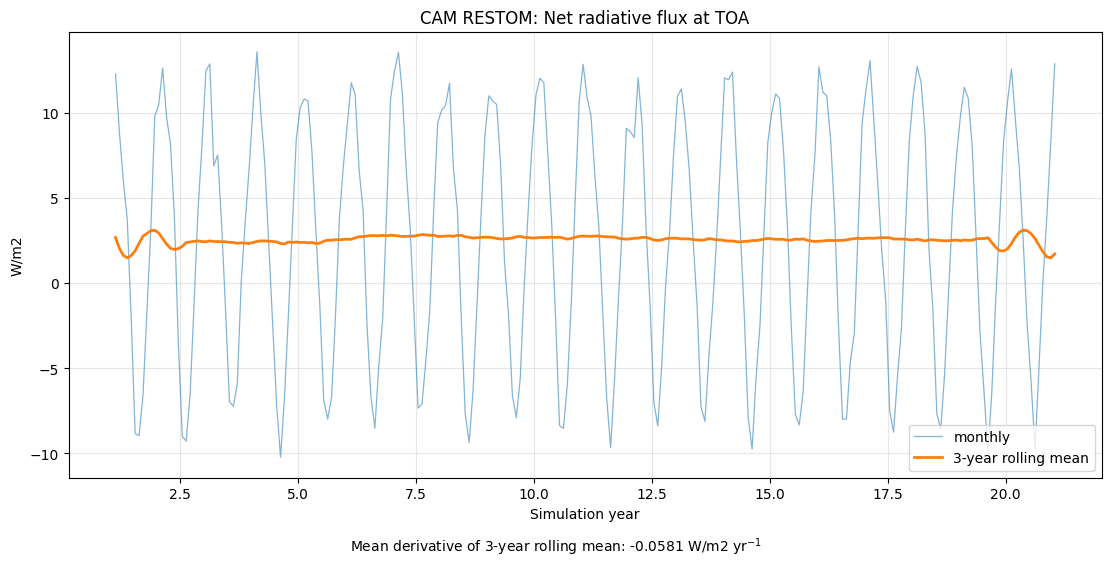

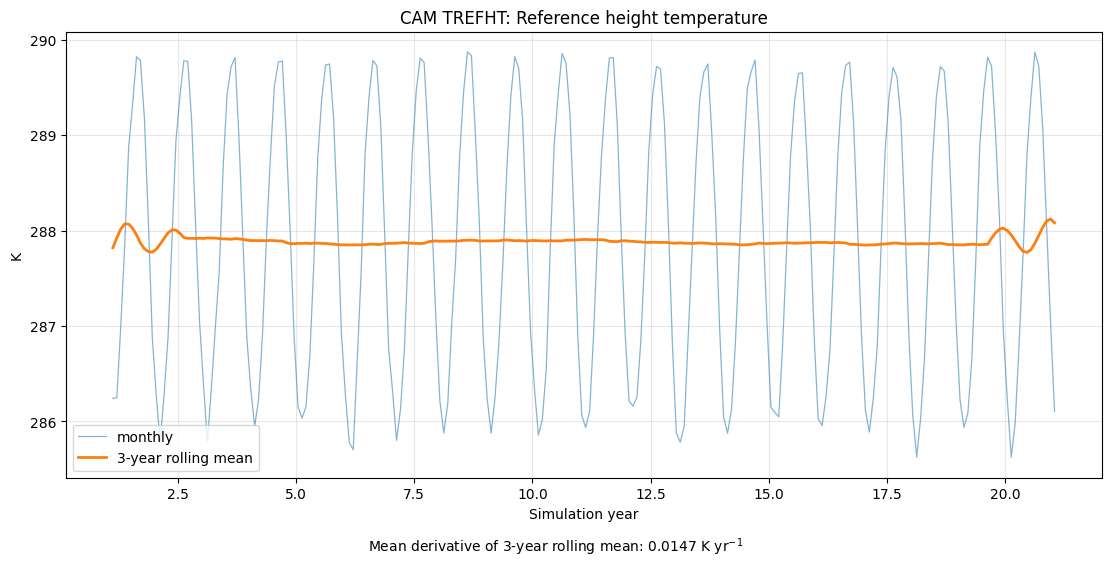

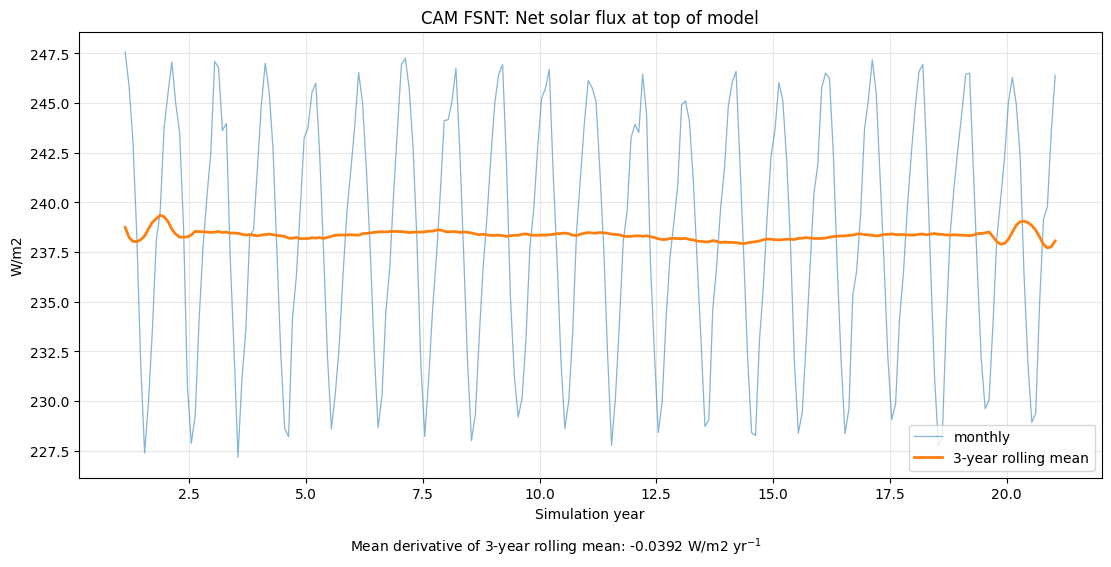

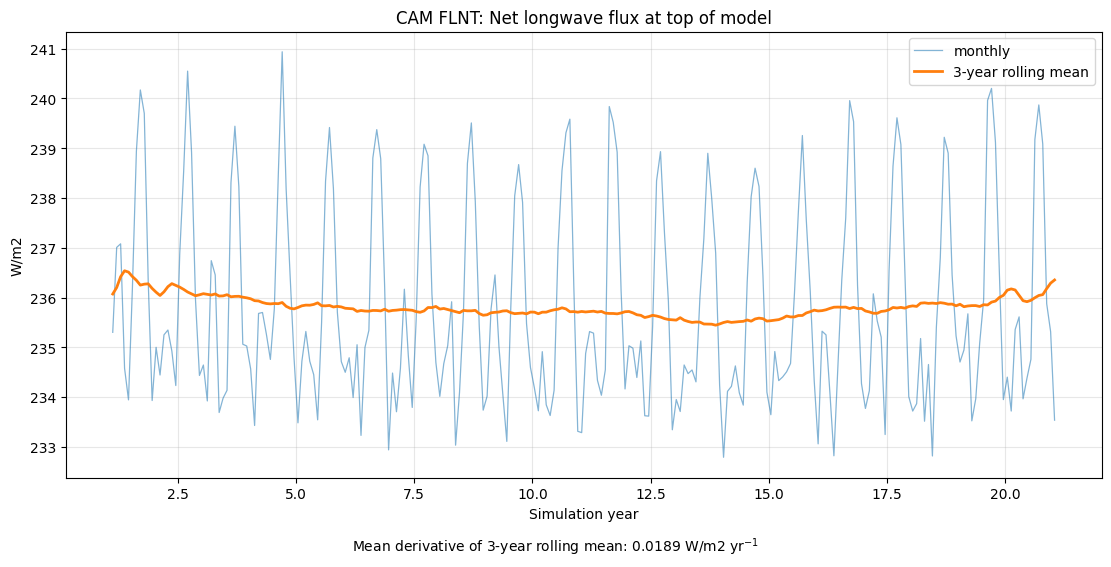

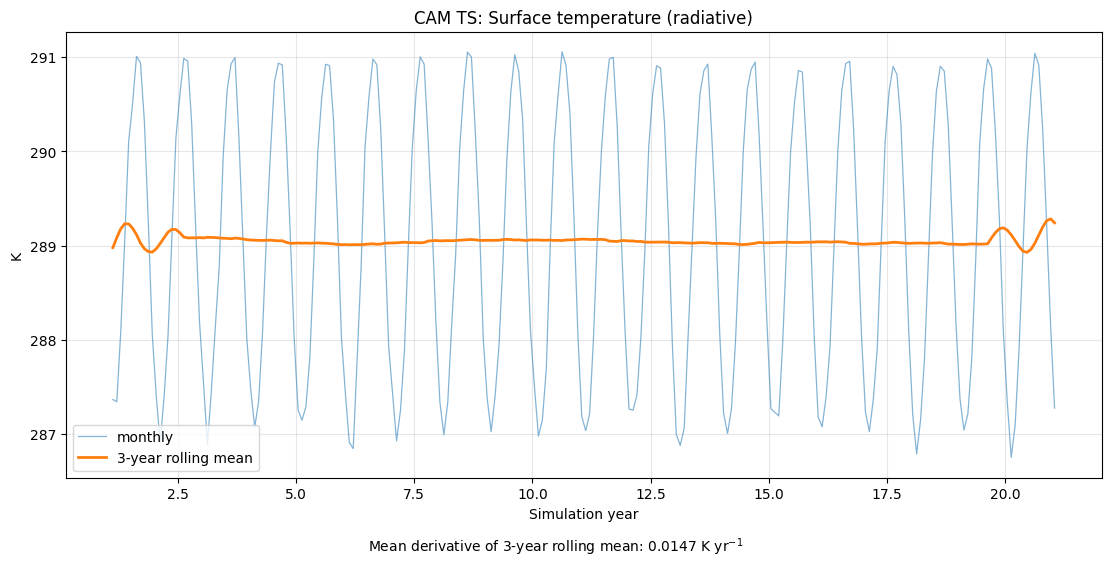

In [7]:
for var in CAM_TIME_SERIES_VARS:
    plot_time_series_with_rolling_derivative(
        cam,
        var,
        rolling_years=CAM_ROLLING_YEARS,
        component="cam",
        depth_select=False,
    )


## CLM: land variables

For `TWS`, `H2OSOI`, and `TSOI`, the notebook selects the soil/depth level closest to 1 m when such a dimension exists. Then it plots the time series, 20-year rolling mean, and derivative.


DEBUG clm GPP
len(years): 8396
first 24 years: [1.04166667 1.04166667 1.04166667 1.04166667 1.04166667 1.04166667
 1.04166667 1.04166667 1.04166667 1.04166667 1.04166667 1.04166667
 1.04166667 1.04166667 1.04166667 1.04166667 1.04166667 1.04166667
 1.04166667 1.04166667 1.04166667 1.04166667 1.04166667 1.04166667]
first 24 y: [1.14904676e-05 2.78521686e-05 2.84801738e-05 2.84390702e-05
 2.81443374e-05 2.77657350e-05 2.69586962e-05 2.75938551e-05
 2.77962789e-05 2.80425701e-05 2.80885038e-05 2.78153743e-05
 2.78584713e-05 2.74486125e-05 2.76838363e-05 2.80354696e-05
 2.80841633e-05 2.76182348e-05 2.74888207e-05 2.76788904e-05
 2.83281080e-05 2.82048916e-05 2.75014053e-05 2.71454168e-05]
median dt: 0.0
samples_per_year: 12
rolling_years: 5
window: 60


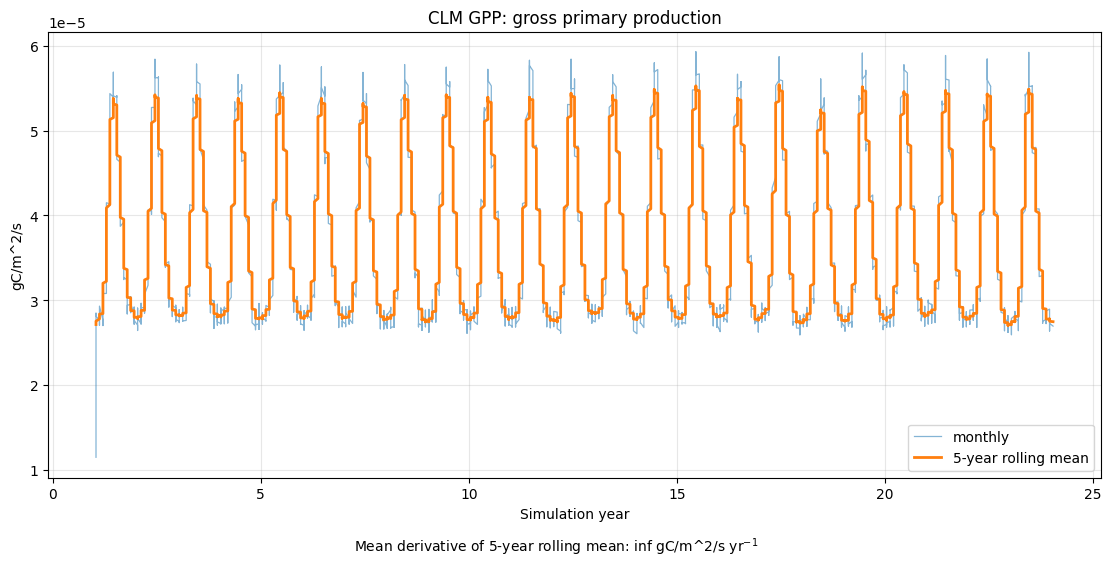


DEBUG clm TOTVEGC
len(years): 8396
first 24 years: [1.04166667 1.04166667 1.04166667 1.04166667 1.04166667 1.04166667
 1.04166667 1.04166667 1.04166667 1.04166667 1.04166667 1.04166667
 1.04166667 1.04166667 1.04166667 1.04166667 1.04166667 1.04166667
 1.04166667 1.04166667 1.04166667 1.04166667 1.04166667 1.04166667]
first 24 y: [5904.89151233 5904.76935922 5904.54239388 5904.32166096 5904.11604463
 5903.91176197 5903.66918723 5903.46419495 5903.31833227 5903.21555268
 5903.10256964 5902.99787892 5902.91593122 5902.81451357 5902.72822517
 5902.69669472 5902.64303292 5902.59870545 5902.52292071 5902.42757559
 5902.32935912 5902.23568612 5902.02595796 5901.86046617]
median dt: 0.0
samples_per_year: 12
rolling_years: 5
window: 60


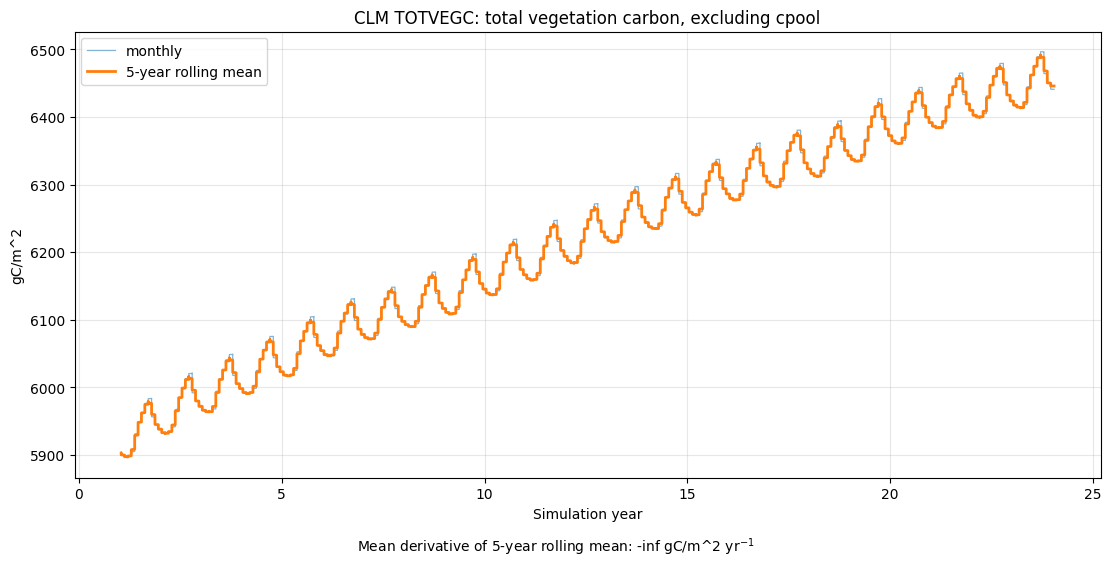


DEBUG clm TOTVEGN
len(years): 8396
first 24 years: [1.04166667 1.04166667 1.04166667 1.04166667 1.04166667 1.04166667
 1.04166667 1.04166667 1.04166667 1.04166667 1.04166667 1.04166667
 1.04166667 1.04166667 1.04166667 1.04166667 1.04166667 1.04166667
 1.04166667 1.04166667 1.04166667 1.04166667 1.04166667 1.04166667]
first 24 y: [69.75421824 69.7511635  69.7450585  69.73917074 69.73401701 69.72912112
 69.72370713 69.71932407 69.71601142 69.71348596 69.71102147 69.70899286
 69.70751117 69.70580625 69.70444371 69.70431165 69.70409273 69.70419673
 69.70377262 69.70310948 69.70236476 69.70171005 69.69855991 69.6965085 ]
median dt: 0.0
samples_per_year: 12
rolling_years: 5
window: 60


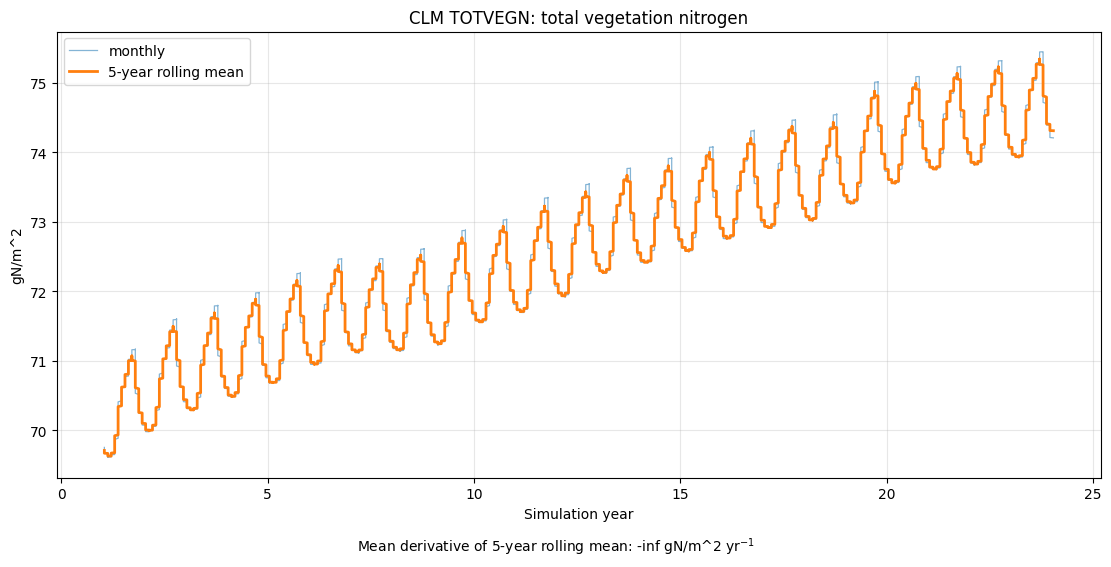


DEBUG clm TWS
len(years): 8396
first 24 years: [1.04166667 1.04166667 1.04166667 1.04166667 1.04166667 1.04166667
 1.04166667 1.04166667 1.04166667 1.04166667 1.04166667 1.04166667
 1.04166667 1.04166667 1.04166667 1.04166667 1.04166667 1.04166667
 1.04166667 1.04166667 1.04166667 1.04166667 1.04166667 1.04166667]
first 24 y: [7494.72899959 7494.92343442 7495.85237051 7496.50470196 7497.01117058
 7497.63172419 7498.64402792 7499.67561895 7500.44315127 7501.34798188
 7502.10928765 7502.54175661 7502.97918519 7503.90174869 7505.12715912
 7505.91373282 7506.63320783 7507.37942507 7507.700612   7507.92028668
 7508.46262604 7508.83814847 7508.92686425 7508.85027157]
median dt: 0.0
samples_per_year: 12
rolling_years: 5
window: 60


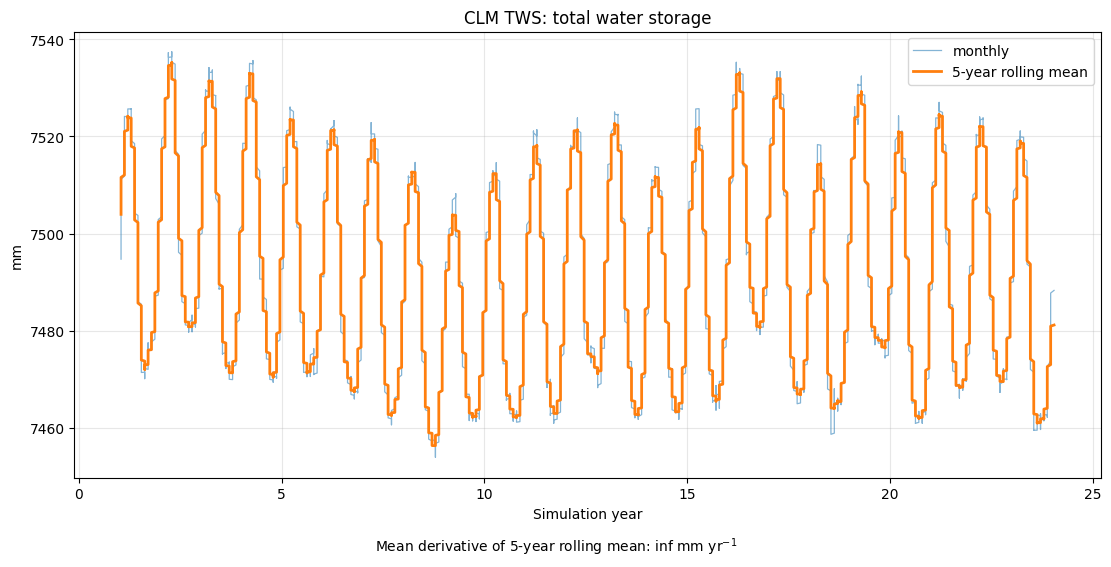


DEBUG clm H2OSOI
len(years): 8396
first 24 years: [1.04166667 1.04166667 1.04166667 1.04166667 1.04166667 1.04166667
 1.04166667 1.04166667 1.04166667 1.04166667 1.04166667 1.04166667
 1.04166667 1.04166667 1.04166667 1.04166667 1.04166667 1.04166667
 1.04166667 1.04166667 1.04166667 1.04166667 1.04166667 1.04166667]
first 24 y: [0.32134474 0.32191185 0.32340514 0.32327748 0.32344934 0.32472251
 0.32618815 0.32696684 0.3269796  0.32752985 0.32747962 0.32712288
 0.32751759 0.32969826 0.33103811 0.33125021 0.33180542 0.33207176
 0.33152003 0.33168925 0.33231025 0.33234454 0.33220072 0.33213445]
median dt: 0.0
samples_per_year: 12
rolling_years: 5
window: 60


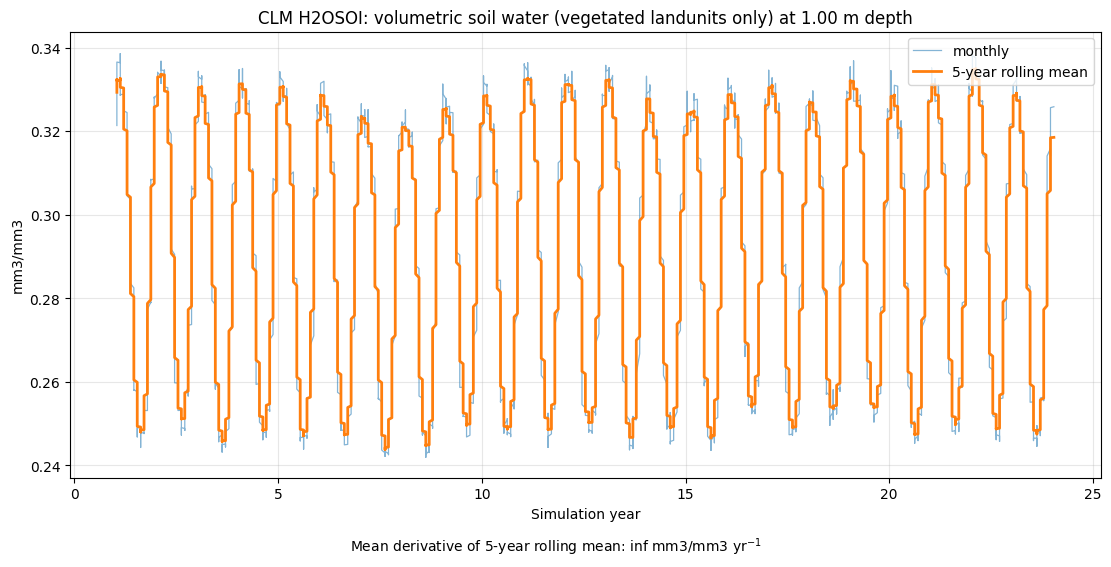

clm: TSOI not found; skipping.


In [21]:
for var in CLM_VARS:
    plot_time_series_with_rolling_derivative(
        clm,
        var,
        rolling_years=CLM_ROLLING_YEARS,
        component="clm",
        depth_select=(var in CLM_DEPTH_VARS),
    )


## CAM gases: vertical profiles and precomputed column burden

For each gas, this section produces:

1. a time-mean global vertical profile from the gas variable, e.g. `CH4(time, lev)`;
2. a column-burden time series if the preprocessed file contains the corresponding variable, e.g. `CH4_COLBURDEN(time)`.

The `*_COLBURDEN` variables should be calculated in the preprocessing script before horizontal averaging, while the original gas fields still have `time, lev, lat, lon`. This is better than reconstructing burden from the already global-mean profiles.

In [9]:
def find_vertical_dim(da):
    """Return the most likely vertical dimension in a CAM gas variable."""
    candidates = ["lev", "ilev", "plev", "level", "z", "altitude"]
    for d in candidates:
        if d in da.dims:
            return d

    # Fallback: any non-time, non-horizontal dimension
    for d in da.dims:
        if d not in ["time", "lat", "lon", "nbnd", "bounds"]:
            return d

    return None


def plot_gas_vertical_profiles_over_time(
    ds,
    gas,
    every=1,
    cmap="viridis",
    alpha=0.8,
):
    """
    Plot global vertical profiles for a CAM gas at different times.
    Each profile is coloured by time.

    Parameters
    ----------
    ds : xarray.Dataset
        CAM dataset.
    gas : str
        Gas variable name, e.g. "CFC115".
    every : int
        Plot every N time steps to avoid overcrowding.
    cmap : str
        Matplotlib colormap.
    alpha : float
        Transparency of each profile line.
    """

    if ds is None or gas not in ds:
        print(f"CAM gas: {gas} not found; skipping profile.")
        return

    da = ds[gas].squeeze(drop=True)

    vdim = find_vertical_dim(da)
    if vdim is None:
        print(f"CAM gas: {gas} has no vertical dimension; skipping profile.")
        return

    if "time" not in da.dims:
        print(f"CAM gas: {gas} has no time dimension; using normal profile plot.")
        plot_gas_vertical_profile(ds, gas)
        return

    # Keep time and vertical dimension, average over all other dimensions
    dims_to_mean = [d for d in da.dims if d not in ["time", vdim]]

    profiles = da.mean(dim=dims_to_mean, skipna=True)
    profiles = profiles.squeeze(drop=True)

    # Subsample time if requested
    profiles = profiles.isel(time=slice(None, None, every))

    y = profiles[vdim].values if vdim in profiles.coords else np.arange(profiles.sizes[vdim])

    ntime = profiles.sizes["time"]
    colors = plt.get_cmap(cmap)(np.linspace(0, 1, ntime))

    fig, ax = plt.subplots(figsize=(6.5, 7), constrained_layout=True)

    for i in range(ntime):
        x = profiles.isel(time=i).values
        ax.plot(
            x,
            y,
            color=colors[i],
            linewidth=1.2,
            alpha=alpha,
        )

    ax.set_title(f"CAM {gas}: global vertical profiles over time")
    ax.set_xlabel(get_units(da) or gas)

    ax.set_ylabel(
        f"{vdim} ({profiles[vdim].attrs.get('units', '')})"
        if vdim in profiles.coords
        else vdim
    )

    ax.grid(True, alpha=0.3)

    # Invert pressure axis
    v_units = str(profiles[vdim].attrs.get("units", "")).lower() if vdim in profiles.coords else ""
    if any(s in v_units for s in ["hpa", "pa", "mbar", "millibar"]):
        ax.invert_yaxis()

    # Colourbar for time
    norm = mpl.colors.Normalize(vmin=0, vmax=ntime - 1)
    sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
    sm.set_array([])

    cbar = fig.colorbar(sm, ax=ax)
    cbar.set_label("Time index")

    # Optional: replace tick labels with actual time values
    tick_locs = np.linspace(0, ntime - 1, min(6, ntime)).astype(int)
    cbar.set_ticks(tick_locs)

    time_labels = [
        str(profiles["time"].values[i])[:10]
        for i in tick_locs
    ]
    cbar.set_ticklabels(time_labels)

    save_or_show(fig, f"cam_{safe_filename(gas)}_vertical_profiles_over_time.png")


def plot_precomputed_gas_column_burden(ds, gas):
    """Plot the precomputed gas column burden from GAS_COLBURDEN."""
    if ds is None:
        print(f"CAM gas: dataset not found; skipping {gas}_COLBURDEN.")
        return

    burden_var = f"{gas}_COLBURDEN"
    if burden_var not in ds:
        print(f"CAM gas: {burden_var} not found; skipping burden plot.")
        return

    plot_time_series_with_rolling_derivative(
        ds,
        burden_var,
        rolling_years=CAM_ROLLING_YEARS,
        component="cam",
        depth_select=False,
    )

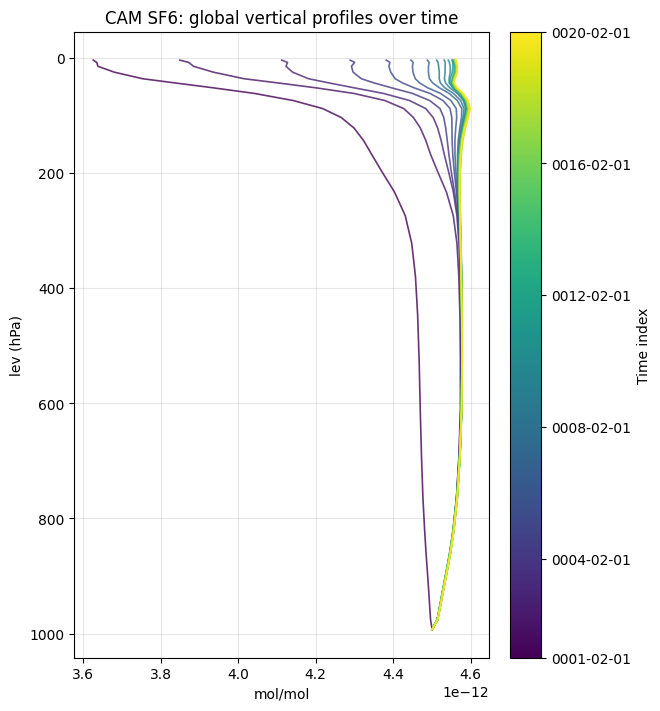

CAM gas: SF6_COLBURDEN not found; skipping burden plot.


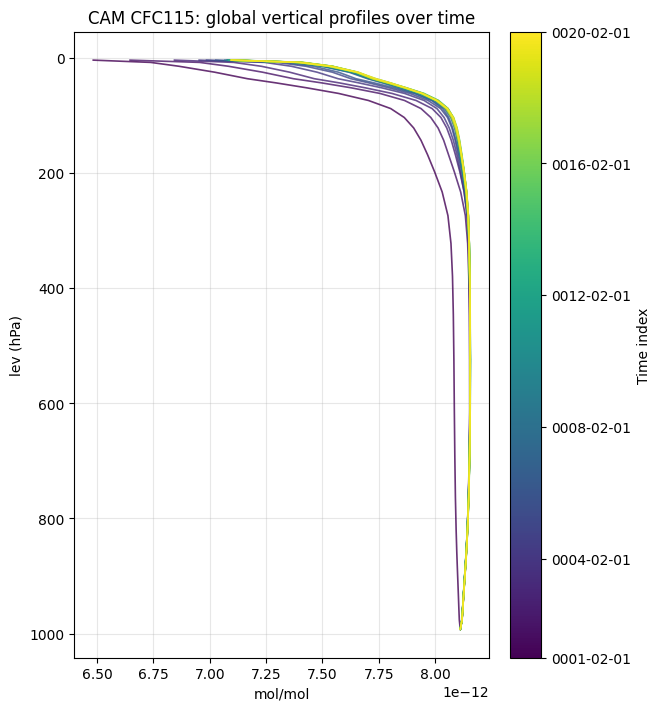

CAM gas: CFC115_COLBURDEN not found; skipping burden plot.
CAM gas: CFC114 not found; skipping profile.
CAM gas: CFC114_COLBURDEN not found; skipping burden plot.


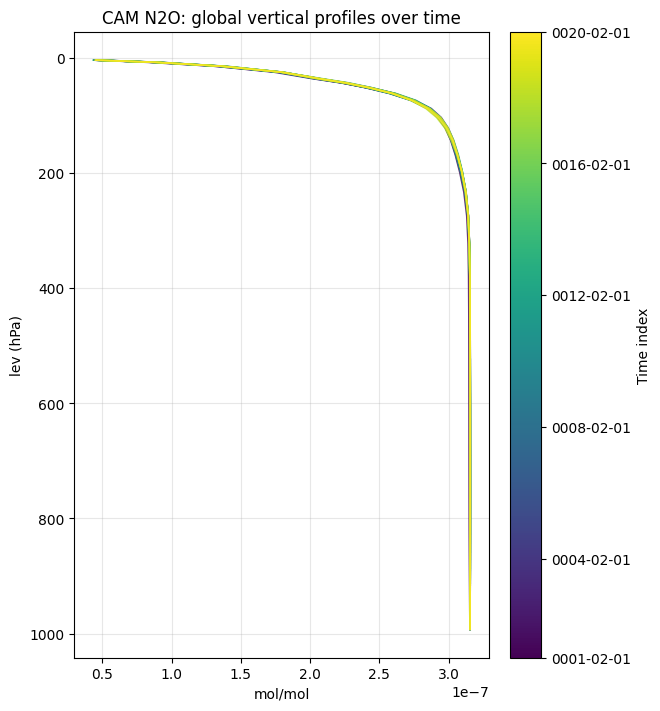

CAM gas: N2O_COLBURDEN not found; skipping burden plot.
CAM gas: CFC12 not found; skipping profile.
CAM gas: CFC12_COLBURDEN not found; skipping burden plot.
CAM gas: CFC113 not found; skipping profile.
CAM gas: CFC113_COLBURDEN not found; skipping burden plot.
CAM gas: CFC11 not found; skipping profile.
CAM gas: CFC11_COLBURDEN not found; skipping burden plot.
CAM gas: HCFC142B not found; skipping profile.
CAM gas: HCFC142B_COLBURDEN not found; skipping burden plot.
CAM gas: HCFC22 not found; skipping profile.
CAM gas: HCFC22_COLBURDEN not found; skipping burden plot.


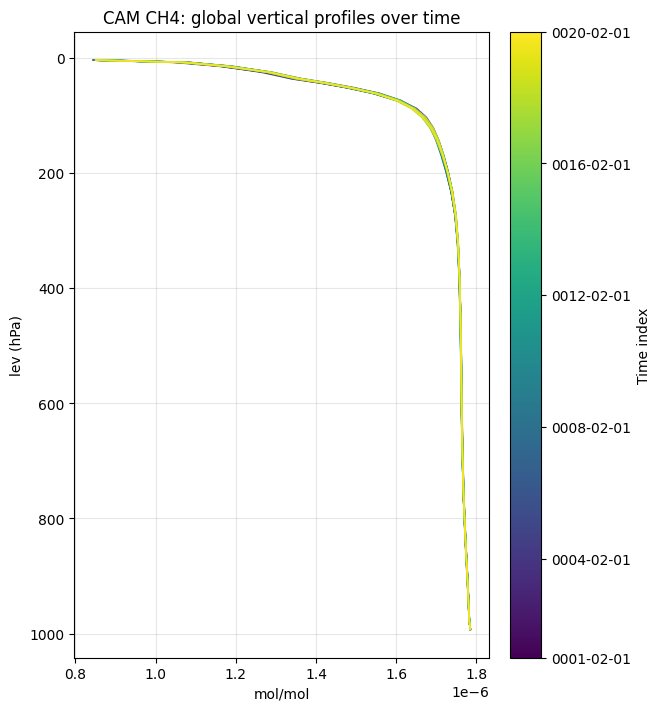

CAM gas: CH4_COLBURDEN not found; skipping burden plot.
CAM gas: HCFC141B not found; skipping profile.
CAM gas: HCFC141B_COLBURDEN not found; skipping burden plot.
CAM gas: OCS not found; skipping profile.
CAM gas: OCS_COLBURDEN not found; skipping burden plot.
CAM gas: CH3CL not found; skipping profile.
CAM gas: CH3CL_COLBURDEN not found; skipping burden plot.
CAM gas: CH3BR not found; skipping profile.
CAM gas: CH3BR_COLBURDEN not found; skipping burden plot.
CAM gas: CH2BR2 not found; skipping profile.
CAM gas: CH2BR2_COLBURDEN not found; skipping burden plot.
CAM gas: CHBR3 not found; skipping profile.
CAM gas: CHBR3_COLBURDEN not found; skipping burden plot.
CAM gas: CO2 not found; skipping profile.
CAM gas: CO2_COLBURDEN not found; skipping burden plot.


In [13]:
for gas in CAM_GAS_VARS:
    plot_gas_vertical_profiles_over_time(cam, gas, every=12)
    plot_precomputed_gas_column_burden(cam, gas)

## Quick output inventory

In [15]:
print(f"Figures saved in: {fig_dir.resolve()}")
for f in sorted(fig_dir.glob("*.png")):
    print(f.name)


Figures saved in: /cluster/home/adelez/BOREAL-FOREST-EXPANSION/diagnostics/check-spinup-equilibrium/equilibrium_figs/equilibrium_NF2100ssp585norbc_tropstratchem_quick_spinup_lcc_f19_f19_20260428
clm_GPP_timeseries.png
clm_H2OSOI_timeseries.png
clm_TOTVEGC_timeseries.png
clm_TOTVEGN_timeseries.png
clm_TWS_timeseries.png


## Notes

- CAM column burdens are expected to come from the preprocessing script as variables named like `CH4_COLBURDEN`, `N2O_COLBURDEN`, etc.
- If CAM gas burden plots are skipped, check that the selected gases were included in `cam_equilibrium_variables.txt` and that the preprocessing script successfully created the corresponding `*_COLBURDEN` variables.
- If the notebook cannot select exactly 1 m for CLM variables, it selects the nearest available soil/depth level and writes the selected depth in the plot title.
- The derivative is a numerical derivative of the centered rolling mean, expressed per simulation year.